<div dir=rtl style="text-align: right">

# שיעור: חתול או כלב? מסווג מאפס עם NumPy
## ירידת גרדיאנט סטוכסטית, והגרדיאנט בשתי דרכים: נומרית וסימבולית

בשיעור הזה נבנה מסווג שמבדיל בין תמונות של חתולים לתמונות של כלבים, **בלי שום ספריית למידת מכונה**. רק פייתון, NumPy, ו-matplotlib בשביל הציורים.

**מה נעשה:**

1. נוריד מאגר תמונות חופשי (CIFAR-10) ונסנן ממנו חתולים וכלבים.
2. נגדיר את המודל הפשוט ביותר שיש: נוירון אחד עם סיגמואיד (רגרסיה לוגיסטית).
3. נגדיר פונקציית הפסד, ונבין מדוע דווקא היא.
4. נאמן את המודל באלגוריתם הקלאסי: **ירידת גרדיאנט סטוכסטית** (SGD).
5. את הגרדיאנט, שהוא לב האלגוריתם, נחשב **בשתי דרכים בלתי תלויות**:
   - **נומרית**: נזיז כל פרמטר קצת, ונמדוד בכמה ההפסד השתנה.
   - **סימבולית**: נגזור את הנוסחה ביד, צעד אחר צעד, עם כלל השרשרת.
6. נשווה: האם שתי הדרכים נותנות את אותו גרדיאנט? את אותו אימון? ובאיזה מחיר?

**ידע מוקדם:** פייתון בסיסי, NumPy בסיסי, ונגזרת של פונקציה במשתנה אחד. את כל השאר נבנה כאן.

האיורים הסטטיים של השיעור נמצאים בתיקייה `img` לצד המחברת (נוצרים על ידי `make_figures.py`).

</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, pickle, tarfile, time, urllib.request

np.random.seed(0)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

# עברית בכותרות של matplotlib: הספרייה python-bidi מסדרת את כיוון הטקסט.
# אם היא לא מותקנת, נסתפק בהיפוך פשוט של המחרוזת.
try:
    from bidi.algorithm import get_display as heb
except ImportError:
    heb = lambda s: s[::-1]

print("NumPy", np.__version__)

NumPy 2.2.6


<div dir=rtl style="text-align: right">

## 1. הנתונים: CIFAR-10

**CIFAR-10** הוא מאגר קלאסי וחופשי של 60,000 תמונות צבע קטנות (32×32 פיקסלים) ב-10 קטגוריות: מטוס, מכונית, ציפור, חתול, צבי, כלב, צפרדע, סוס, ספינה ומשאית. הוא נאסף באוניברסיטת טורונטו (Krizhevsky, 2009) ומשמש עד היום כמגרש משחקים סטנדרטי לאלגוריתמים של ראייה ממוחשבת.

אנחנו ניקח ממנו רק שתי קטגוריות: **חתול** (מספר 3) ו**כלב** (מספר 5). נקבל 10,000 תמונות אימון (5,000 מכל סוג) ו-2,000 תמונות מבחן.

הקוד הבא מוריד את הקובץ (כ-170MB) פעם אחת ושומר אותו בתיקייה `cifar10_data`. בהרצות הבאות הוא ישתמש בעותק המקומי.

</div>

In [2]:
URL      = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
DATA_DIR = "cifar10_data"
BATCHES  = os.path.join(DATA_DIR, "cifar-10-batches-py")

def download_cifar10():
    if os.path.exists(BATCHES):
        print("CIFAR-10 כבר קיים בדיסק")
        return
    os.makedirs(DATA_DIR, exist_ok=True)
    tar_path = os.path.join(DATA_DIR, "cifar-10.tar.gz")

    def progress(count, block_size, total_size):
        pct = min(count * block_size / total_size * 100, 100)
        print(f"\r  מוריד... {pct:5.1f}%", end="", flush=True)

    urllib.request.urlretrieve(URL, tar_path, reporthook=progress)
    print("\n  מחלץ...")
    with tarfile.open(tar_path) as tar:
        tar.extractall(DATA_DIR)
    os.remove(tar_path)
    print("  סיימנו.")

download_cifar10()

CIFAR-10 כבר קיים בדיסק


<div dir=rtl style="text-align: right">

הקובץ מגיע בפורמט `pickle` של פייתון: כל "אצווה" (batch) היא מילון עם מערך `data` של 10,000 שורות באורך 3072, ורשימת `labels` באותו אורך.

כל שורה במערך היא תמונה אחת, פרוסה לווקטור: 1024 הערכים הראשונים הם ערוץ האדום (32 שורות של 32 פיקסלים), אחריהם הירוק ואז הכחול. נסדר אותה מחדש למערך תלת-ממדי של 32 שורות, 32 עמודות ו-3 ערוצי צבע, כדי שנוכל להציג אותה, ונשמור רק את החתולים והכלבים.

</div>

In [3]:
def load_batch(name):
    with open(os.path.join(BATCHES, name), "rb") as f:
        d = pickle.load(f, encoding="bytes")
    X = d[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)   # (N, 32, 32, 3)
    y = np.array(d[b"labels"])
    return X, y

CAT, DOG = 3, 5

def only_cats_and_dogs(X, y):
    keep = (y == CAT) | (y == DOG)
    return X[keep], (y[keep] == DOG).astype(np.float64)        # חתול = 0, כלב = 1

train_parts = [load_batch(f"data_batch_{i}") for i in range(1, 6)]
X_img, y = only_cats_and_dogs(np.concatenate([p[0] for p in train_parts]),
                              np.concatenate([p[1] for p in train_parts]))
X_test_img, y_test = only_cats_and_dogs(*load_batch("test_batch"))

print(f"אימון: {len(X_img)} תמונות, מהן {int((y == 0).sum())} חתולים ו-{int((y == 1).sum())} כלבים")
print(f"מבחן:  {len(X_test_img)} תמונות, מהן {int((y_test == 0).sum())} חתולים ו-{int((y_test == 1).sum())} כלבים")
print("X_img.shape =", X_img.shape)

אימון: 10000 תמונות, מהן 5000 חתולים ו-5000 כלבים
מבחן:  2000 תמונות, מהן 1000 חתולים ו-1000 כלבים
X_img.shape = (10000, 32, 32, 3)


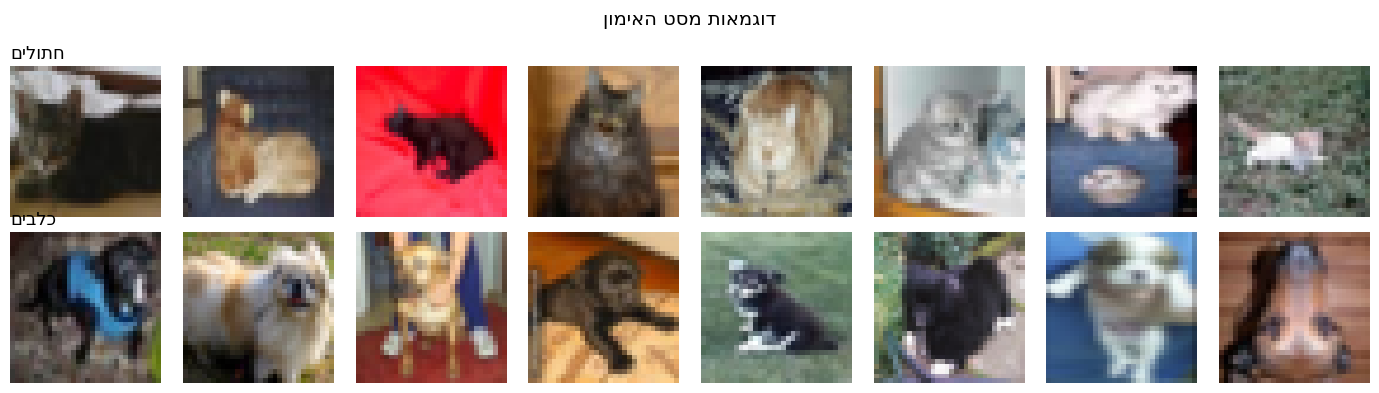

In [4]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for row, (label, name) in enumerate([(0, 'חתולים'), (1, 'כלבים')]):
    idx = np.where(y == label)[0][:8]
    for col, i in enumerate(idx):
        axes[row, col].imshow(X_img[i])
        axes[row, col].axis('off')
    axes[row, 0].set_title(heb(name), loc='left', fontsize=13)
plt.suptitle(heb('דוגמאות מסט האימון'), fontsize=14)
plt.tight_layout()
plt.show()

<div dir=rtl style="text-align: right">

### מתמונה לווקטור

המודל שלנו לא "רואה" תמונה. הוא רואה **וקטור של מספרים**. נפרוס כל תמונה 32×32×3 לווקטור באורך

$$n = 32 \cdot 32 \cdot 3 = 3072$$

ונסמן אותו $\mathbf{x} \in \mathbb{R}^{3072}$.

### נרמול (standardization)

ערכי הפיקסלים הם שלמים בין 0 ל-255. נעשה שני צעדי עיבוד מקדים:

1. **חלוקה ב-255**, כדי לעבור לטווח $[0,1]$.
2. **תקנון של כל פיצ'ר**: מכל פיקסל $j$ (מתוך 3072) נחסיר את הממוצע שלו על פני סט האימון ונחלק בסטיית התקן שלו:

$$x_j \leftarrow \frac{x_j - \mu_j}{\sigma_j}$$

למה זה חשוב לירידת גרדיאנט? בהמשך נראה שגודל הצעד בקואורדינטה $j$ פרופורציוני ל-$x_j$. אם פיקסלים שונים חיים בסקאלות שונות, קצב למידה אחד יהיה גדול מדי לחלקם וקטן מדי לאחרים. כשכל הפיצ'רים בסקאלה דומה, קצב למידה אחד מתאים לכולם.

**שימו לב:** את $\mu_j$ ו-$\sigma_j$ מחשבים **על סט האימון בלבד**, ומחילים אותם גם על סט המבחן. סט המבחן מדמה תמונות שנפגוש בעתיד, ואסור שהוא "ידלוף" לשום חישוב של האימון.

נפריש גם 1,000 תמונות מסט האימון ל**סט אימות** (validation). נשתמש בו כדי לעקוב אחרי האימון, בלי לגעת בסט המבחן עד הסוף.

</div>

In [5]:
def to_vectors(X_images):
    return X_images.reshape(len(X_images), -1).astype(np.float64) / 255.0   # (N, 3072)

X_all  = to_vectors(X_img)
X_test = to_vectors(X_test_img)

mu    = X_all.mean(axis=0)             # ממוצע של כל פיקסל על פני סט האימון
sigma = X_all.std(axis=0) + 1e-8       # סטיית תקן (עם הגנה מחלוקה באפס)
X_all  = (X_all  - mu) / sigma
X_test = (X_test - mu) / sigma

# פיצול לאימון ואימות
perm = np.random.permutation(len(X_all))
val_idx, train_idx = perm[:1000], perm[1000:]
X_val, y_val     = X_all[val_idx],   y[val_idx]
X_train, y_train = X_all[train_idx], y[train_idx]

n = X_train.shape[1]
print(f"אימון: {len(X_train)} וקטורים   אימות: {len(X_val)}   מבחן: {len(X_test)}   אורך כל וקטור: {n}")
print(f"ממוצע אחרי תקנון: {X_train.mean():.4f}   סטיית תקן: {X_train.std():.4f}")

אימון: 9000 וקטורים   אימות: 1000   מבחן: 2000   אורך כל וקטור: 3072
ממוצע אחרי תקנון: -0.0013   סטיית תקן: 1.0000


<div dir=rtl style="text-align: right">

## 2. המודל: נוירון אחד

<img src="img/pipeline.png" alt="הצינור: תמונה, וקטור, נוירון, סיגמואיד, הפסד" style="width:100%; max-width:1200px">

המודל הפשוט ביותר שאפשר לדמיין: **צירוף לינארי של הפיקסלים**, ואחריו "מעיכה" לטווח של הסתברות.

$$z = \mathbf{w}^{\top}\mathbf{x} + b = \sum_{j=1}^{n} w_j x_j + b$$

$$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

- $\mathbf{w} \in \mathbb{R}^{3072}$ הוא וקטור **המשקולות**: כמה כל פיקסל "מצביע" לטובת כלב (משקל חיובי) או לטובת חתול (משקל שלילי).
- $b$ הוא **ההטיה** (bias): הנטייה הבסיסית של המודל, עוד לפני שהסתכל על התמונה.
- $\sigma$ היא **פונקציית הסיגמואיד**, שממפה כל מספר ממשי לטווח $(0,1)$. נפרש את $\hat{y}$ כהסתברות שהתמונה היא כלב.

ההחלטה: אם $\hat{y} > 0.5$ נאמר "כלב", אחרת "חתול". שימו לב ש-$\sigma(z) > 0.5$ בדיוק כאשר $z > 0$, כלומר גבול ההחלטה הוא $\mathbf{w}^{\top}\mathbf{x} + b = 0$: מישור-על אחד שמחלק את המרחב בן 3072 הממדים לשניים. המודל הזה נקרא **רגרסיה לוגיסטית**, והוא מסווג לינארי.

בסך הכל: $n + 1 = 3073$ פרמטרים נלמדים. נסמן את כולם יחד $\boldsymbol{\theta} = (\mathbf{w}, b)$.

### הסיגמואיד ונגזרתה

תכונה אחת של $\sigma$ תשרת אותנו בהמשך. נגזור לפי כלל השרשרת (חזקה $-1$ של ביטוי, שהנגזרת הפנימית שלו היא $-e^{-z}$):

$$\sigma(z) = (1 + e^{-z})^{-1}
\quad\Longrightarrow\quad
\sigma'(z) = -(1 + e^{-z})^{-2} \cdot (-e^{-z}) = \frac{e^{-z}}{(1 + e^{-z})^{2}}$$

נפרק את השבר למכפלה של שני שברים:

$$\sigma'(z) = \underbrace{\frac{1}{1 + e^{-z}}}_{\sigma(z)} \cdot \underbrace{\frac{e^{-z}}{1 + e^{-z}}}_{1 - \sigma(z)}$$

בדקו שהשבר השני הוא באמת $1 - \sigma(z)$:

$$1 - \sigma(z) = \frac{1 + e^{-z}}{1 + e^{-z}} - \frac{1}{1 + e^{-z}} = \frac{e^{-z}}{1 + e^{-z}}$$

ולכן:

$$\boxed{\;\sigma'(z) = \sigma(z)\,\big(1 - \sigma(z)\big)\;}$$

הנגזרת מתבטאת דרך ערך הפונקציה עצמה. ברגע שחישבנו את $\hat{y}$ במעבר קדימה, הנגזרת שלה מגיעה כמעט בחינם.

</div>

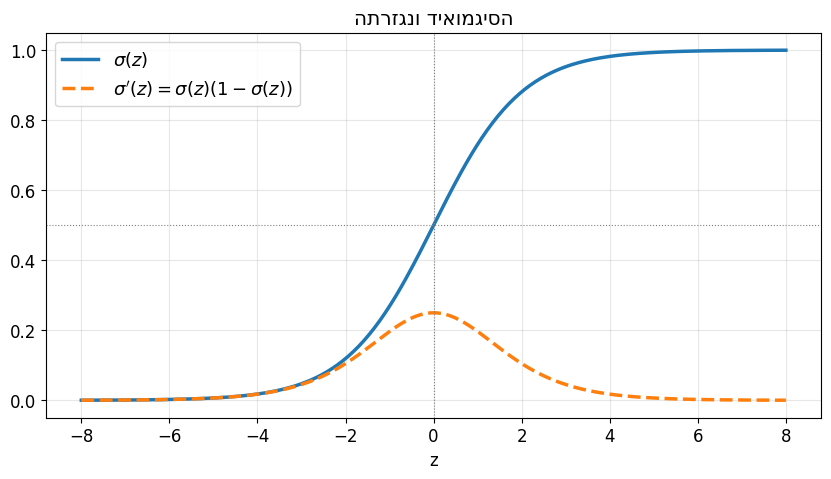

In [6]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

z = np.linspace(-8, 8, 400)
s = sigmoid(z)
plt.plot(z, s, lw=2.5, label=r'$\sigma(z)$')
plt.plot(z, s * (1 - s), lw=2.5, ls='--', label=r"$\sigma'(z)=\sigma(z)(1-\sigma(z))$")
plt.axhline(0.5, color='gray', lw=0.8, ls=':')
plt.axvline(0, color='gray', lw=0.8, ls=':')
plt.xlabel('z'); plt.legend(fontsize=13); plt.grid(alpha=0.3)
plt.title(heb('הסיגמואיד ונגזרתה'))
plt.show()

In [7]:
def forward(w, b, X):
    """ההסתברות שכל תמונה ב-X היא כלב. X בגודל (m, n)."""
    return sigmoid(X @ w + b)

def predict(w, b, X):
    return (forward(w, b, X) > 0.5).astype(np.float64)

def accuracy(w, b, X, y):
    return np.mean(predict(w, b, X) == y)

<div dir=rtl style="text-align: right">

## 3. פונקציית ההפסד

אנחנו צריכים מספר אחד שאומר "כמה המודל טועה" על תמונה, ושאותו נוכל למזער. לתמונה עם תווית $y \in \{0, 1\}$ וחיזוי $\hat{y} \in (0,1)$ נגדיר:

$$\ell(\hat{y}, y) = -\Big[\, y \ln \hat{y} + (1 - y)\ln(1 - \hat{y}) \,\Big]$$

זהו **הפסד האנטרופיה הצולבת הבינארית** (binary cross-entropy), שנקרא לפעמים גם log loss. נבין אותו לפי מקרים:

- אם $y = 1$ (כלב): $\ell = -\ln \hat{y}$. כש-$\hat{y} \to 1$ ההפסד שואף ל-0, וכש-$\hat{y} \to 0$ ההפסד מתפוצץ לאינסוף.
- אם $y = 0$ (חתול): $\ell = -\ln(1 - \hat{y})$. אותו דבר, בתמונת מראה.

כלומר: ביטחון בתשובה הנכונה כמעט לא נענש, וביטחון בתשובה הלא נכונה נענש בחומרה.

### מאיפה זה מגיע? נראוּת (likelihood)

המודל טוען ש-$P(\text{כלב} \mid \mathbf{x}) = \hat{y}$ ו-$P(\text{חתול} \mid \mathbf{x}) = 1 - \hat{y}$. אפשר לכתוב את שניהם בנוסחה אחת:

$$P(y \mid \mathbf{x}) = \hat{y}^{\,y}\,(1 - \hat{y})^{\,1 - y}$$

(הציבו $y=1$ ואז $y=0$ ובדקו.) ניקח לוגריתם ונהפוך סימן, וקיבלנו בדיוק את $\ell$. לכן **מזעור ההפסד שקול למקסום ההסתברות שהמודל מייחס לתוויות האמיתיות**. זהו עקרון הנראוּת המקסימלית, והוא הסיבה שדווקא לוגריתם ולא, למשל, ריבוע ההפרש.

### ההפסד על אצווה

על קבוצה של $m$ תמונות (כל סט האימון, או מיני-אצווה) נמצע:

$$J(\mathbf{w}, b) = \frac{1}{m}\sum_{i=1}^{m} \ell(\hat{y}_i, y_i)
\qquad\text{כאשר}\qquad \hat{y}_i = \sigma(\mathbf{w}^{\top}\mathbf{x}_i + b)$$

$J$ היא פונקציה של 3073 משתנים (הפרמטרים); הנתונים קבועים. **כל האימון הוא חיפוש אחר המינימום של $J$.**

</div>

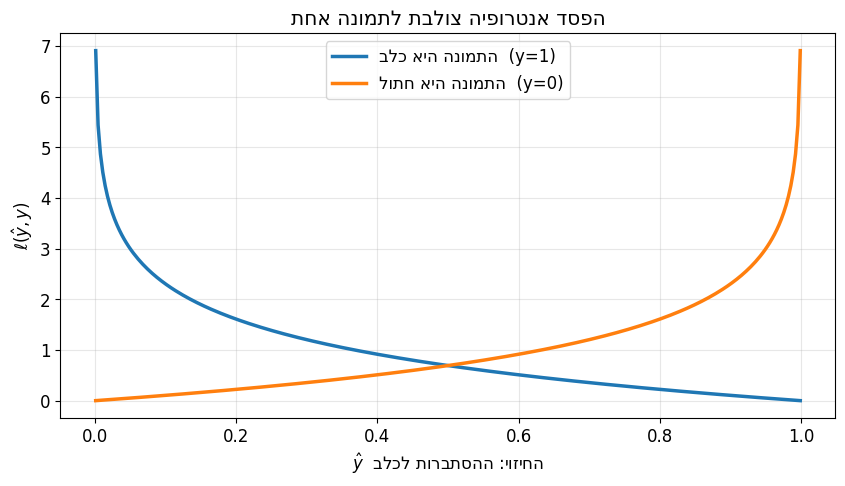

הפסד התחלתי על סט האימון: 0.6940
דיוק התחלתי:              0.484
ln(2) = 0.6931   <- ההפסד של מודל שאומר 0.5 על כל תמונה


In [8]:
def loss(w, b, X, y):
    """אנטרופיה צולבת בינארית, ממוצעת על האצווה."""
    p = np.clip(forward(w, b, X), 1e-12, 1 - 1e-12)     # הגנה מ-log(0)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

# איך נראה ההפסד של תמונה אחת כפונקציה של החיזוי?
p = np.linspace(0.001, 0.999, 300)
plt.plot(p, -np.log(p),     lw=2.5, label=heb('התמונה היא כלב') + '  (y=1)')
plt.plot(p, -np.log(1 - p), lw=2.5, label=heb('התמונה היא חתול') + '  (y=0)')
plt.xlabel(r'$\hat{y}$' + '  ' + heb('החיזוי: ההסתברות לכלב'))
plt.ylabel(r'$\ell(\hat{y}, y)$')
plt.title(heb('הפסד אנטרופיה צולבת לתמונה אחת'))
plt.legend(fontsize=12); plt.grid(alpha=0.3)
plt.show()

# ההפסד והדיוק של מודל שעדיין לא למד כלום
w0 = np.random.randn(n) * 0.001
b0 = 0.0
print(f"הפסד התחלתי על סט האימון: {loss(w0, b0, X_train, y_train):.4f}")
print(f"דיוק התחלתי:              {accuracy(w0, b0, X_train, y_train):.3f}")
print(f"ln(2) = {np.log(2):.4f}   <- ההפסד של מודל שאומר 0.5 על כל תמונה")

<div dir=rtl style="text-align: right">

## 4. ירידת גרדיאנט סטוכסטית (SGD)

### הגרדיאנט

**הגרדיאנט** של $J$ הוא וקטור כל הנגזרות החלקיות:

$$\nabla J = \left( \frac{\partial J}{\partial w_1},\; \frac{\partial J}{\partial w_2},\; \dots,\; \frac{\partial J}{\partial w_n},\; \frac{\partial J}{\partial b} \right)$$

$\frac{\partial J}{\partial w_j}$ עונה על השאלה: "אם אזיז את $w_j$ קצת, ואשאיר את כל השאר במקום, בכמה ישתנה $J$?" הגרדיאנט מצביע לכיוון שבו $J$ **עולה** הכי מהר, ולכן $-\nabla J$ הוא כיוון הירידה התלול ביותר.

### ירידת גרדיאנט

מתחילים מפרמטרים כלשהם, ובכל צעד זזים קצת נגד הגרדיאנט:

$$\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \eta\, \nabla J(\boldsymbol{\theta})$$

$\eta$ (אטא) הוא **קצב הלמידה**: כמה רחוק ללכת בכל צעד. גדול מדי, ונקפוץ מעבר למינימום; קטן מדי, ונזחל.

### הבעיה: כל צעד יקר

$J$ מוגדרת על **כל** סט האימון, $N = 9000$ תמונות. גרדיאנט מדויק אחד דורש מעבר על כולן, ובסופו עושים צעד קטן אחד. ב-ImageNet יש 1.2 מיליון תמונות, ובמודלי שפה גדולים מאות מיליארדי מילים; שם זה פשוט לא בא בחשבון.

### הפתרון: אומדן אקראי

במקום הגרדיאנט המדויק, בכל צעד נגריל **מיני-אצווה** $B$ של $m$ תמונות (למשל 64) ונחשב את הגרדיאנט רק עליהן:

$$\nabla J_B(\boldsymbol{\theta}) = \frac{1}{m}\sum_{i \in B} \nabla \ell_i(\boldsymbol{\theta})$$

זהו אומדן **רועש** של הגרדיאנט האמיתי, אבל אומדן **לא מוטה**: בממוצע על כל הבחירות האפשריות של $B$ מקבלים בדיוק את $\nabla J$,

$$\mathbb{E}_B\big[\nabla J_B\big] = \nabla J$$

והוא זול פי $N/m$. הרעש לא רק שאינו מזיק, ברשתות עמוקות הוא אפילו עוזר לברוח ממינימומים מקומיים רדודים. (למודל שלנו, שהוא קמור, יש מינימום אחד בלבד; שם הרעש הוא רק מחיר.)

<img src="img/gd_vs_sgd.png" alt="ירידת גרדיאנט מלאה מול סטוכסטית" style="width:85%; max-width:900px">

זהו **SGD**, Stochastic Gradient Descent. "סטוכסטי" פירושו אקראי (מיוונית *stochos*, ניחוש או מטרה). הרעיון מגיע ממאמר של רובינס ומונרו מ-1951 על "קירוב סטוכסטי", והוא עד היום הבסיס של כמעט כל אימון של רשת נוירונים.

**אפוק** (epoch): מעבר אחד על כל סט האימון. בכל אפוק מערבבים את הסדר, חותכים למיני-אצוות, ועושים צעד אחד לכל אצווה.

הלולאה עצמה קצרה. שימו לב שהיא מקבלת את **פונקציית הגרדיאנט כפרמטר**: כך נוכל להריץ בדיוק את אותו אימון, פעם עם גרדיאנט נומרי ופעם עם גרדיאנט סימבולי.

</div>

In [9]:
def sgd_train(grad_fn, w, b, X, y, lr=0.01, batch_size=64, epochs=1,
              max_steps=None, seed=0, eval_sets=None):
    """
    SGD קלאסי.  grad_fn(w, b, X_batch, y_batch) מחזירה (grad_w, grad_b).
    מחזירה את הפרמטרים המאומנים והיסטוריה: הפסד לכל צעד, ומדדים לכל אפוק.
    """
    rng = np.random.default_rng(seed)         # קובע את סדר המיני-אצוות
    w = w.copy()
    history = {'step_loss': [], 'epoch': {}}
    steps = 0
    for epoch in range(1, epochs + 1):
        order = rng.permutation(len(X))
        for start in range(0, len(X), batch_size):
            idx = order[start:start + batch_size]
            history['step_loss'].append(loss(w, b, X[idx], y[idx]))
            grad_w, grad_b = grad_fn(w, b, X[idx], y[idx])
            w -= lr * grad_w                   # הצעד עצמו
            b -= lr * grad_b
            steps += 1
            if max_steps is not None and steps >= max_steps:
                return w, b, history
        if eval_sets:                          # מדדים בסוף כל אפוק
            for name, (Xe, ye) in eval_sets.items():
                history['epoch'].setdefault(name + '_loss', []).append(loss(w, b, Xe, ye))
                history['epoch'].setdefault(name + '_acc',  []).append(accuracy(w, b, Xe, ye))
            print(f"epoch {epoch:2d}  " + "   ".join(
                f"{k}: {v[-1]:.3f}" for k, v in history['epoch'].items()))
    return w, b, history

<div dir=rtl style="text-align: right">

## 5. דרך א': הגרדיאנט הנומרי

### מהגדרת הנגזרת

הנגזרת של פונקציה במשתנה אחד מוגדרת כגבול:

$$f'(w) = \lim_{\varepsilon \to 0} \frac{f(w + \varepsilon) - f(w)}{\varepsilon}$$

במחשב אין גבול, אבל יש $\varepsilon$ קטן. ניקח את **ההפרש הקדמי**:

$$f'(w) \approx \frac{f(w + \varepsilon) - f(w)}{\varepsilon}$$

כמה זה מדויק? נפתח את $f(w+\varepsilon)$ לטור טיילור סביב $w$:

$$f(w + \varepsilon) = f(w) + \varepsilon f'(w) + \frac{\varepsilon^2}{2} f''(w) + \frac{\varepsilon^3}{6} f'''(w) + \cdots$$

נציב בהפרש הקדמי:

$$\frac{f(w+\varepsilon) - f(w)}{\varepsilon} = f'(w) + \underbrace{\frac{\varepsilon}{2} f''(w) + \cdots}_{\text{שגיאה מסדר } \varepsilon}$$

השגיאה פרופורציונית ל-$\varepsilon$. אפשר לעשות יותר טוב עם **ההפרש המרכזי**, שמסתכל צעד קדימה וצעד אחורה:

$$f'(w) \approx \frac{f(w + \varepsilon) - f(w - \varepsilon)}{2\varepsilon}$$

נכתוב גם את $f(w - \varepsilon)$ בטור טיילור (אותו טור, עם $-\varepsilon$ במקום $\varepsilon$):

$$f(w - \varepsilon) = f(w) - \varepsilon f'(w) + \frac{\varepsilon^2}{2} f''(w) - \frac{\varepsilon^3}{6} f'''(w) + \cdots$$

נחסר את השני מהראשון. האיברים עם החזקות הזוגיות ($f$, $f''$) מתבטלים, ואלו עם החזקות האי-זוגיות מוכפלים:

$$f(w + \varepsilon) - f(w - \varepsilon) = 2\varepsilon f'(w) + \frac{\varepsilon^3}{3} f'''(w) + \cdots$$

$$\Longrightarrow\qquad \frac{f(w+\varepsilon) - f(w-\varepsilon)}{2\varepsilon} = f'(w) + \underbrace{\frac{\varepsilon^2}{6} f'''(w) + \cdots}_{\text{שגיאה מסדר } \varepsilon^2}$$

השגיאה פרופורציונית ל-$\varepsilon^2$: אם נקטין את $\varepsilon$ פי 10, השגיאה תקטן פי 100. במחיר של חישוב אחד נוסף של $f$ קיבלנו קירוב הרבה יותר טוב.

<img src="img/secant_tangent.png" alt="משיק מול מיתר: הפרש קדמי והפרש מרכזי" style="width:100%; max-width:1200px">

### מנגזרת לגרדיאנט: קואורדינטה אחת בכל פעם

$J$ היא פונקציה של 3073 משתנים. נגזרת חלקית לפי $\theta_j$ פירושה: מזיזים **רק** את $\theta_j$, וכל השאר קפואים. עם $\mathbf{e}_j$ וקטור היחידה בכיוון $j$ (אפסים בכל מקום חוץ מ-1 במקום ה-$j$):

$$\frac{\partial J}{\partial \theta_j} \approx \frac{J(\boldsymbol{\theta} + \varepsilon\,\mathbf{e}_j) - J(\boldsymbol{\theta} - \varepsilon\,\mathbf{e}_j)}{2\varepsilon}$$

<img src="img/nudge.png" alt="תזוזה של קואורדינטה אחת" style="width:100%; max-width:1200px">

זה כל האלגוריתם. הוא לא יודע שום דבר על המבנה של $J$: הוא מתייחס אליה כאל **קופסה שחורה** שמקבלת פרמטרים ומחזירה מספר. זה היופי שלו, וגם המחיר שלו: לכל קואורדינטה שני חישובים מלאים של $J$, ובסך הכל $2(n+1) = 6146$ מעברים על המיני-אצווה כדי לקבל גרדיאנט אחד.

</div>

In [10]:
def numeric_gradient(w, b, X, y, eps=1e-5):
    """גרדיאנט בהפרשים מרכזיים: מזיזים קואורדינטה אחת בכל פעם."""
    grad_w = np.zeros_like(w)
    for j in range(len(w)):
        w_plus,  w_minus  = w.copy(), w.copy()
        w_plus[j]  += eps
        w_minus[j] -= eps
        grad_w[j] = (loss(w_plus, b, X, y) - loss(w_minus, b, X, y)) / (2 * eps)
    grad_b = (loss(w, b + eps, X, y) - loss(w, b - eps, X, y)) / (2 * eps)
    return grad_w, grad_b

# מיני-אצווה אחת לבדיקות
batch = np.random.choice(len(X_train), 64, replace=False)
Xb, yb = X_train[batch], y_train[batch]

t0 = time.perf_counter()
gw_num, gb_num = numeric_gradient(w0, b0, Xb, yb)
t_num = time.perf_counter() - t0
print(f"גרדיאנט נומרי אחד על אצווה של 64 תמונות: {t_num:.2f} שניות  ({2 * (n + 1):,} חישובי הפסד)")
print(f"חמשת הרכיבים הראשונים: {gw_num[:5]}")
print(f"הנגזרת לפי b: {gb_num:.6f}")

גרדיאנט נומרי אחד על אצווה של 64 תמונות: 0.39 שניות  (6,146 חישובי הפסד)
חמשת הרכיבים הראשונים: [0.03398002 0.02644647 0.02702962 0.04838162 0.0461511 ]
הנגזרת לפי b: -0.032168


<div dir=rtl style="text-align: right">

## 6. דרך ב': הגרדיאנט הסימבולי

עכשיו נפתח את הקופסה השחורה. $J$ היא ממוצע של $\ell_i$, ונגזרת של ממוצע היא ממוצע הנגזרות, אז מספיק לגזור את ההפסד של **תמונה אחת** $\ell(\hat{y}, y)$ לפי $\mathbf{w}$ ו-$b$.

### שרשרת של שלוש פונקציות

$\ell$ תלוי ב-$\mathbf{w}$ רק דרך $\hat{y}$, ו-$\hat{y}$ תלוי ב-$\mathbf{w}$ רק דרך $z$:

$$\mathbf{w}, b \;\xrightarrow{\;z = \mathbf{w}^{\top}\mathbf{x} + b\;}\; z \;\xrightarrow{\;\hat{y} = \sigma(z)\;}\; \hat{y} \;\xrightarrow{\;\ell(\hat{y},\, y)\;}\; \ell$$

**כלל השרשרת** אומר שנגזרת של הרכבה היא מכפלת הנגזרות של החוליות:

$$\frac{\partial \ell}{\partial w_j} = \frac{\partial \ell}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial w_j}$$

<img src="img/chain_graph.png" alt="גרף החישוב וכלל השרשרת" style="width:100%; max-width:1200px">

נחשב כל חוליה בנפרד.

### חוליה 1: ההפסד לפי החיזוי

$$\ell = -\big[y \ln \hat{y} + (1-y)\ln(1-\hat{y})\big]$$

נגזור לפי $\hat{y}$. נזכור ש-$\frac{d}{du}\ln u = \frac{1}{u}$, ושבנגזרת של $\ln(1-\hat{y})$ מצטרף מינוס מהנגזרת הפנימית:

$$\frac{\partial \ell}{\partial \hat{y}} = -\left[\frac{y}{\hat{y}} - \frac{1-y}{1-\hat{y}}\right] = -\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}}$$

### חוליה 2: החיזוי לפי $z$

זו בדיוק נגזרת הסיגמואיד שהוכחנו בסעיף 2:

$$\frac{\partial \hat{y}}{\partial z} = \sigma'(z) = \hat{y}\,(1-\hat{y})$$

### הכפלה: ההפסד לפי $z$

$$\frac{\partial \ell}{\partial z} = \frac{\partial \ell}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} = \left(-\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}}\right)\hat{y}\,(1-\hat{y})$$

נפתח סוגריים. באיבר הראשון $\hat{y}$ מצטמצם, ובשני $(1-\hat{y})$ מצטמצם:

$$\frac{\partial \ell}{\partial z} = -y\,(1-\hat{y}) + (1-y)\,\hat{y} = -y + y\hat{y} + \hat{y} - y\hat{y}$$

$$\boxed{\;\frac{\partial \ell}{\partial z} = \hat{y} - y\;}$$

עצרו רגע על התוצאה הזאת. כל הלוגריתמים והשברים נעלמו, ונשאר **החיזוי פחות האמת**. אם חזינו 0.9 והתמונה היא חתול ($y=0$), האות שחוזר אחורה הוא $+0.9$; אם היא כלב ($y=1$), האות הוא $-0.1$. הסיגמואיד והאנטרופיה הצולבת נבנו זו לזו: הנגזרת של האחת מבטלת בדיוק את הפנים של השנייה. (זו לא מקריות. כך קורה תמיד כשמצמידים פונקציית הפסד מסוג "נראוּת" לפונקציית קישור מאותה משפחה מעריכית.)

### חוליה 3: $z$ לפי הפרמטרים

$z = \sum_j w_j x_j + b$ הוא לינארי בפרמטרים, ולכן:

$$\frac{\partial z}{\partial w_j} = x_j, \qquad\qquad \frac{\partial z}{\partial b} = 1$$

### ההרכבה הסופית

$$\boxed{\;\frac{\partial \ell}{\partial w_j} = (\hat{y} - y)\,x_j \qquad\qquad \frac{\partial \ell}{\partial b} = \hat{y} - y\;}$$

### מתמונה אחת לאצווה, ולכתיב מטריצי

נסדר את $m$ התמונות של האצווה בשורות של מטריצה $X \in \mathbb{R}^{m \times n}$, ואת התוויות והחיזויים בווקטורים $\mathbf{y}, \hat{\mathbf{y}} \in \mathbb{R}^{m}$. אז $\hat{\mathbf{y}} = \sigma(X\mathbf{w} + b)$ (הסיגמואיד פועלת איבר-איבר), וממוצע הנגזרות הוא:

$$\nabla_{\mathbf{w}} J = \frac{1}{m}\sum_{i=1}^{m} (\hat{y}_i - y_i)\,\mathbf{x}_i = \frac{1}{m}\, X^{\top}(\hat{\mathbf{y}} - \mathbf{y})
\qquad\qquad
\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m} (\hat{y}_i - y_i)$$

**פרשנות:** הגרדיאנט לפי $\mathbf{w}$ הוא **סכום משוקלל של התמונות עצמן**, כשכל תמונה משוקללת בשגיאה עליה. צעד SGD, $\mathbf{w} \leftarrow \mathbf{w} - \eta \nabla_{\mathbf{w}} J$, מוסיף למשקולות קצת מכל תמונת כלב שפוספסה ומחסיר קצת מכל תמונת חתול שפוספסה. תמונות שסווגו נכון בביטחון ($\hat{y}_i \approx y_i$) כמעט לא משפיעות.

**המחיר:** מעבר קדימה אחד ($X\mathbf{w}$) ומכפלה אחת נוספת ($X^{\top}(\hat{\mathbf{y}} - \mathbf{y})$). שתיהן $O(mn)$. במקום 6146 מעברים על האצווה, שניים.

</div>

In [11]:
def symbolic_gradient(w, b, X, y):
    """הגרדיאנט לפי הנוסחה שגזרנו: (1/m) Xᵀ(ŷ - y)."""
    y_hat = forward(w, b, X)
    delta = (y_hat - y) / len(y)          # (ŷ - y) / m
    return X.T @ delta, delta.sum()

t0 = time.perf_counter()
for _ in range(100):
    gw_sym, gb_sym = symbolic_gradient(w0, b0, Xb, yb)
t_sym = (time.perf_counter() - t0) / 100
print(f"גרדיאנט סימבולי אחד על אותה אצווה: {t_sym * 1000:.3f} אלפיות שנייה")
print(f"חמשת הרכיבים הראשונים: {gw_sym[:5]}")
print(f"הנגזרת לפי b: {gb_sym:.6f}")
print(f"\nיחס זמנים, נומרי/סימבולי: פי {t_num / t_sym:,.0f}")

גרדיאנט סימבולי אחד על אותה אצווה: 0.099 אלפיות שנייה
חמשת הרכיבים הראשונים: [0.03398002 0.02644647 0.02702962 0.04838162 0.0461511 ]
הנגזרת לפי b: -0.032168

יחס זמנים, נומרי/סימבולי: פי 3,897


<div dir=rtl style="text-align: right">

## 7. ההשוואה

יש לנו שתי פונקציות שאמורות לחשב את אותו וקטור בן 3073 מספרים, בשתי דרכים שאין ביניהן שום דבר משותף: האחת רק מזיזה פרמטרים ומודדת, השנייה רק מיישמת נוסחה שגזרנו על נייר. אם שתיהן מסכימות, זו ראיה חזקה ששתיהן נכונות. טעות בגזירה (סימן הפוך, גורם 2 שנשכח) תקפוץ מיד.

### 7.1 אותו גרדיאנט?

נמדוד את הפער ב**שגיאה יחסית**, שאינה תלויה בסקאלה של הגרדיאנט:

$$\text{err} = \frac{\|\mathbf{g}_{\text{num}} - \mathbf{g}_{\text{sym}}\|_2}{\|\mathbf{g}_{\text{num}}\|_2 + \|\mathbf{g}_{\text{sym}}\|_2}$$

כלל אצבע מקובל: פחות מ-$10^{-7}$ מצוין; סביב $10^{-4}$ חשוד; מעל $10^{-2}$ כמעט בוודאות באג. זו בדיוק הבדיקה (gradient check) שמפתחי ספריות למידה עמוקה מריצים על כל שכבה חדשה שהם כותבים.

</div>

    j          numeric         symbolic           diff
    0     0.0339800231     0.0339800231       2.58e-12
    1     0.0264464735     0.0264464735      -8.85e-12
    2     0.0270296234     0.0270296234      -1.41e-12
  100     0.0238035670     0.0238035670       1.04e-12
 1000     0.0004907450     0.0004907450      -4.65e-12
 2000    -0.0867592592    -0.0867592592       2.39e-12
 3071    -0.0293829874    -0.0293829874      -4.09e-12
    b    -0.0321677373    -0.0321677373       4.89e-13

relative error = 3.35e-11   <- על כל 3072 המשקולות יחד
max |diff|     = 1.28e-11


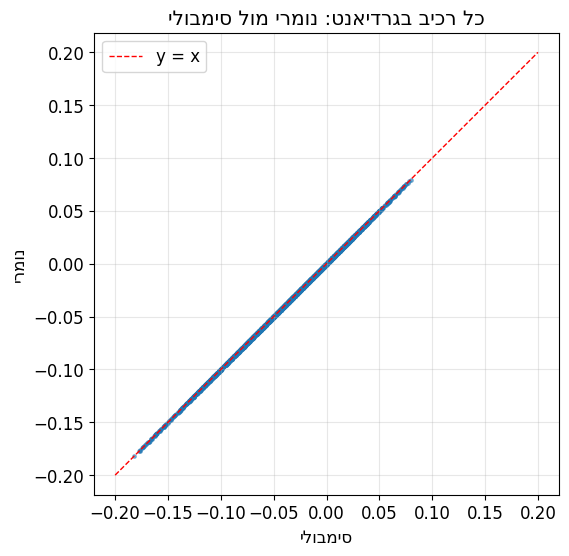

In [12]:
def relative_error(g1, g2):
    return np.linalg.norm(g1 - g2) / (np.linalg.norm(g1) + np.linalg.norm(g2))

print(f"{'j':>5} {'numeric':>16} {'symbolic':>16} {'diff':>14}")
for j in [0, 1, 2, 100, 1000, 2000, 3071]:
    print(f"{j:>5} {gw_num[j]:>16.10f} {gw_sym[j]:>16.10f} {gw_num[j] - gw_sym[j]:>14.2e}")
print(f"{'b':>5} {gb_num:>16.10f} {gb_sym:>16.10f} {gb_num - gb_sym:>14.2e}")

print(f"\nrelative error = {relative_error(gw_num, gw_sym):.2e}   <- על כל 3072 המשקולות יחד")
print(f"max |diff|     = {np.abs(gw_num - gw_sym).max():.2e}")

plt.figure(figsize=(6, 6))
plt.scatter(gw_sym, gw_num, s=6, alpha=0.5)
lim = np.abs(gw_sym).max() * 1.1
plt.plot([-lim, lim], [-lim, lim], 'r--', lw=1, label='y = x')
plt.xlabel(heb('סימבולי')); plt.ylabel(heb('נומרי'))
plt.title(heb('כל רכיב בגרדיאנט: נומרי מול סימבולי'))
plt.legend(); plt.grid(alpha=0.3); plt.axis('equal')
plt.show()

<div dir=rtl style="text-align: right">

### 7.2 כמה קטן צריך להיות $\varepsilon$?

לפי טור טיילור, ככל ש-$\varepsilon$ קטן יותר הקירוב טוב יותר. אז למה לא $\varepsilon = 10^{-15}$?

כי המחשב מייצג מספרים ב**נקודה צפה** עם דיוק סופי. ב-float64 יש כ-16 ספרות עשרוניות משמעותיות, כלומר שגיאת עיגול יחסית של $\delta \approx 2 \cdot 10^{-16}$ בכל פעולה. במונה $J(\boldsymbol{\theta} + \varepsilon\mathbf{e}_j) - J(\boldsymbol{\theta} - \varepsilon\mathbf{e}_j)$ אנחנו מחסרים שני מספרים **כמעט שווים**, ונשארים עם הפרש זעיר שנושא בתוכו שגיאת עיגול מסדר $\delta \cdot |J|$. אחרי חלוקה ב-$2\varepsilon$:

$$\text{שגיאת עיגול} \approx \frac{\delta\,|J|}{2\varepsilon}$$

השגיאה הזאת **גדלה** כש-$\varepsilon$ קטן. השגיאה הכוללת היא סכום של שני מקורות מנוגדים:

$$\text{err}(\varepsilon) \approx \underbrace{\frac{\varepsilon^2}{6}\,|J'''|}_{\text{קיטום (טיילור)}} + \underbrace{\frac{\delta\,|J|}{2\varepsilon}}_{\text{עיגול}}$$

גזירה לפי $\varepsilon$ והשוואה לאפס נותנת מינימום ב-$\varepsilon^{*} \sim \delta^{1/3} \approx 10^{-5}$. נבדוק את זה בניסוי: נרוץ על טווח של ערכי $\varepsilon$, ונמדוד את השגיאה היחסית מול הגרדיאנט הסימבולי. (הריצה לוקחת כמה שניות: 12 גרדיאנטים נומריים.)

</div>

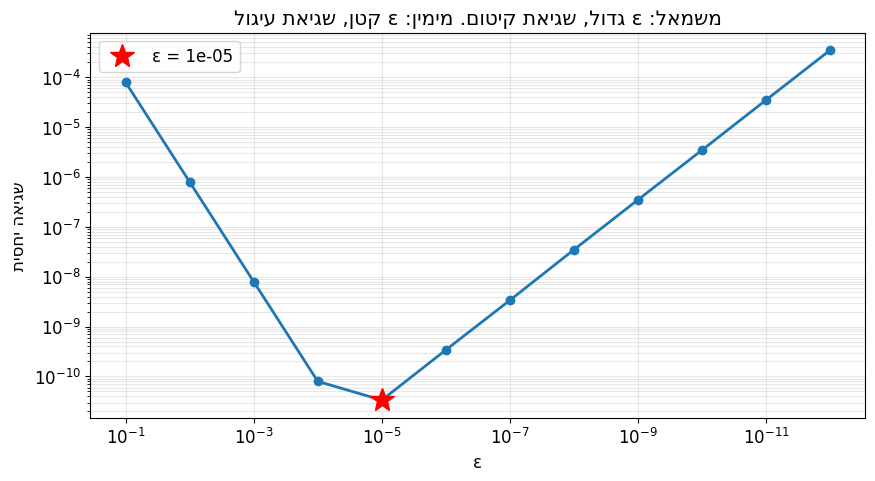

In [13]:
eps_values = 10.0 ** np.arange(-1, -13, -1)
errors = [relative_error(numeric_gradient(w0, b0, Xb, yb, eps=e)[0], gw_sym) for e in eps_values]

plt.loglog(eps_values, errors, 'o-', lw=2)
best = int(np.argmin(errors))
plt.plot(eps_values[best], errors[best], 'r*', ms=18, label=f'ε = {eps_values[best]:.0e}')
plt.gca().invert_xaxis()
plt.xlabel('ε'); plt.ylabel(heb('שגיאה יחסית'))
plt.title(heb('משמאל: ε גדול, שגיאת קיטום. מימין: ε קטן, שגיאת עיגול'))
plt.legend(); plt.grid(alpha=0.3, which='both')
plt.show()

<div dir=rtl style="text-align: right">

הגרף מאשר את החשבון: משמאל השיפוע הוא 2 (הקטנת $\varepsilon$ פי 10 מקטינה את השגיאה פי 100, כמו $\varepsilon^2$), מימין השיפוע הוא $-1$ (הקטנת $\varepsilon$ פי 10 **מגדילה** את השגיאה פי 10, כמו $1/\varepsilon$), והמינימום בסביבות $10^{-5}$ עם שגיאה יחסית של כ-$10^{-11}$. זה הכי טוב שאפשר לקבל מהפרשים סופיים ב-float64, ובזה נסתפק.

</div>

<div dir=rtl style="text-align: right">

### 7.3 אותו אימון?

עכשיו נריץ את **אותה** לולאת SGD פעמיים: אותם פרמטרים התחלתיים, אותו קצב למידה, אותן מיני-אצוות (אותו זרע אקראי). ההבדל היחיד: מי מחשב את הגרדיאנט. נעצור אחרי 200 צעדים, כי הגרסה הנומרית איטית (כדקה וחצי).

שימו לב שההפסד על מיני-אצווה קופץ מצעד לצעד: זה הרעש של SGD, כל אצווה היא דגימה אחרת. ממוצע נע (הקו האדום) מחליק את הרעש ומראה את המגמה.

</div>

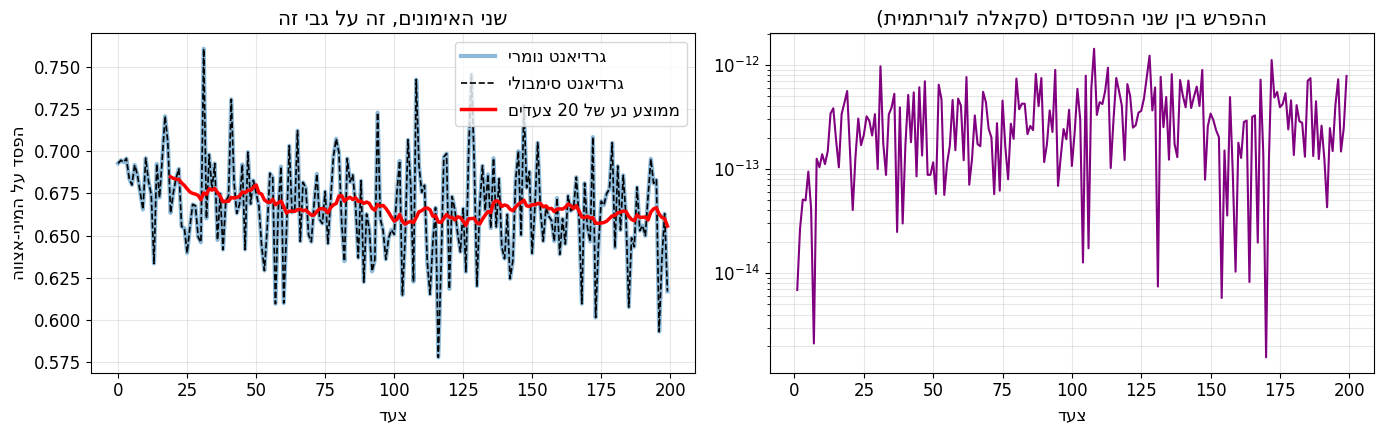

זמן אימון, נומרי:      71.3 שניות
זמן אימון, סימבולי:   0.072 שניות   (פי 988 מהר יותר)
max |loss_num - loss_sym| = 1.43e-12   <- ההפרש המקסימלי בין עקומות ההפסד
|w_num - w_sym|           = 5.95e-12   <- המרחק בין וקטורי המשקולות בסוף
|w_sym|                   = 0.105
דיוק על סט האימות, נומרי: 0.568   סימבולי: 0.568


In [14]:
STEPS, LR = 200, 0.002

t0 = time.perf_counter()
w_num, b_num, hist_num = sgd_train(numeric_gradient,  w0, b0, X_train, y_train, lr=LR, epochs=5, max_steps=STEPS, seed=1)
time_num = time.perf_counter() - t0

t0 = time.perf_counter()
w_sym, b_sym, hist_sym = sgd_train(symbolic_gradient, w0, b0, X_train, y_train, lr=LR, epochs=5, max_steps=STEPS, seed=1)
time_sym = time.perf_counter() - t0

loss_num, loss_sym = np.array(hist_num['step_loss']), np.array(hist_sym['step_loss'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(loss_num, lw=3, alpha=0.5, label=heb('גרדיאנט נומרי'))
axes[0].plot(loss_sym, lw=1.2, ls='--', color='black', label=heb('גרדיאנט סימבולי'))
window = 20
smooth = np.convolve(loss_sym, np.ones(window) / window, mode='valid')
axes[0].plot(np.arange(window - 1, STEPS), smooth, lw=2.5, color='red', label=heb('ממוצע נע של 20 צעדים'))
axes[0].set_xlabel(heb('צעד')); axes[0].set_ylabel(heb('הפסד על המיני-אצווה'))
axes[0].set_title(heb('שני האימונים, זה על גבי זה')); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].semilogy(np.arange(1, STEPS), np.abs(loss_num - loss_sym)[1:], lw=1.5, color='purple')
axes[1].set_xlabel(heb('צעד')); axes[1].set_title(heb('ההפרש בין שני ההפסדים (סקאלה לוגריתמית)'))
axes[1].grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

print(f"זמן אימון, נומרי:   {time_num:7.1f} שניות")
print(f"זמן אימון, סימבולי: {time_sym:7.3f} שניות   (פי {time_num / time_sym:,.0f} מהר יותר)")
print(f"max |loss_num - loss_sym| = {np.abs(loss_num - loss_sym).max():.2e}   <- ההפרש המקסימלי בין עקומות ההפסד")
print(f"|w_num - w_sym|           = {np.linalg.norm(w_num - w_sym):.2e}   <- המרחק בין וקטורי המשקולות בסוף")
print(f"|w_sym|                   = {np.linalg.norm(w_sym):.3f}")
print(f"דיוק על סט האימות, נומרי: {accuracy(w_num, b_num, X_val, y_val):.3f}   סימבולי: {accuracy(w_sym, b_sym, X_val, y_val):.3f}")

<div dir=rtl style="text-align: right">

### 7.4 סיכום ההשוואה

| | נומרי | סימבולי |
|---|---|---|
| **מה צריך לדעת על $J$** | כלום: קופסה שחורה | את הנוסחה, ולגזור אותה |
| **עלות לגרדיאנט אחד** | $2(n+1)$ חישובי $J$, כלומר $O(mn^2)$ | מעבר קדימה ואחורה, $O(mn)$ |
| **דיוק** | קירוב, שגיאה $\sim 10^{-10}$ במקרה הטוב | מדויק עד לעיגול של המחשב |
| **סיכון** | $\varepsilon$ גרוע | טעות בגזירה |
| **תפקיד בפועל** | **בדיקה** של הגרסה הסימבולית | **האימון עצמו** |

שתי הדרכים נתנו את אותו גרדיאנט עד לספרה העשירית, ואותו מסלול אימון בדיוק. ההבדל היחיד הוא המחיר: פי אלפים. ככל שהמודל גדול יותר הפער גדל, כי הגרסה הנומרית משלמת מעבר מלא על כל פרמטר. במודל עם מיליארד פרמטרים היא לא רלוונטית אפילו לצעד אחד.

הלקח המעשי: **גוזרים ביד (או נותנים לספרייה לגזור אוטומטית), ובודקים נומרית.** בשיעורים הבאים, כשנגזור רשתות מסובכות יותר, `numeric_gradient` תישאר איתנו ככלי הבדיקה.

</div>

<div dir=rtl style="text-align: right">

## 8. אימון מלא

השתכנענו שהגרדיאנט הסימבולי נכון, וראינו שהוא זול פי אלפים. מכאן נשתמש רק בו, ונאמן את המודל על כל סט האימון למספר אפוקים. אחרי כל אפוק נמדוד את ההפסד והדיוק גם על סט האימות, כדי לראות מתי הלמידה מפסיקה להועיל.

</div>

In [15]:
w, b, hist = sgd_train(symbolic_gradient, w0, b0, X_train, y_train,
                       lr=0.002, batch_size=64, epochs=30, seed=2,
                       eval_sets={'train': (X_train, y_train), 'val': (X_val, y_val)})

epoch  1  train_loss: 0.662   train_acc: 0.606   val_loss: 0.678   val_acc: 0.583
epoch  2  train_loss: 0.653   train_acc: 0.621   val_loss: 0.672   val_acc: 0.591


epoch  3  train_loss: 0.648   train_acc: 0.634   val_loss: 0.673   val_acc: 0.587


epoch  4  train_loss: 0.647   train_acc: 0.630   val_loss: 0.677   val_acc: 0.588
epoch  5  train_loss: 0.647   train_acc: 0.627   val_loss: 0.675   val_acc: 0.593


epoch  6  train_loss: 0.647   train_acc: 0.624   val_loss: 0.682   val_acc: 0.591


epoch  7  train_loss: 0.640   train_acc: 0.644   val_loss: 0.672   val_acc: 0.604
epoch  8  train_loss: 0.641   train_acc: 0.638   val_loss: 0.679   val_acc: 0.596


...

epoch 24  train_loss: 0.632   train_acc: 0.646   val_loss: 0.679   val_acc: 0.588


epoch 25  train_loss: 0.623   train_acc: 0.659   val_loss: 0.678   val_acc: 0.612
epoch 26  train_loss: 0.625   train_acc: 0.657   val_loss: 0.676   val_acc: 0.609


epoch 27  train_loss: 0.624   train_acc: 0.657   val_loss: 0.675   val_acc: 0.598


epoch 28  train_loss: 0.624   train_acc: 0.658   val_loss: 0.680   val_acc: 0.595
epoch 29  train_loss: 0.621   train_acc: 0.658   val_loss: 0.676   val_acc: 0.610


epoch 30  train_loss: 0.620   train_acc: 0.661   val_loss: 0.681   val_acc: 0.603


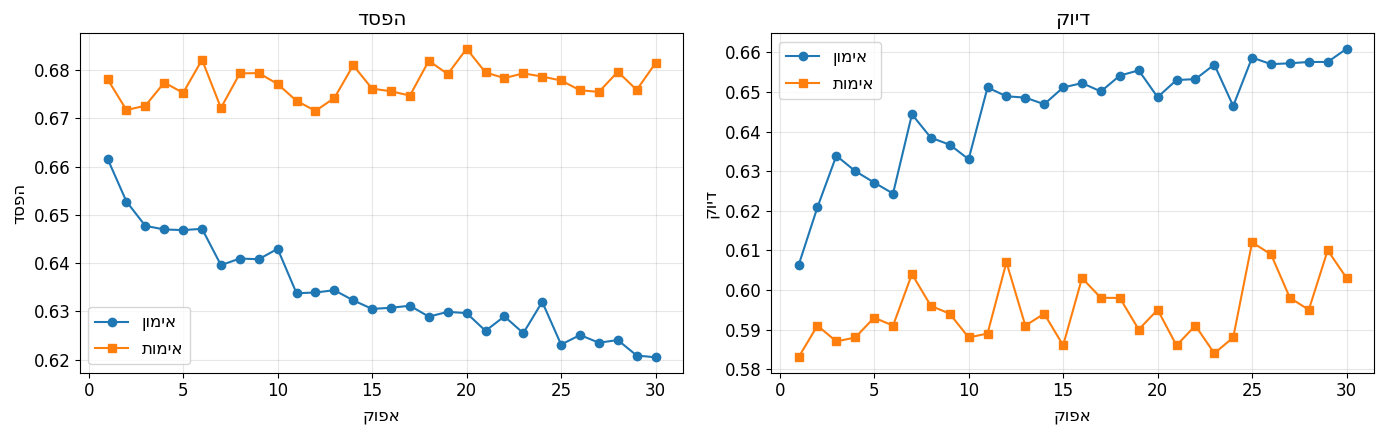

In [16]:
ep = hist['epoch']
epochs = np.arange(1, len(ep['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(epochs, ep['train_loss'], 'o-', label=heb('אימון'))
axes[0].plot(epochs, ep['val_loss'],   's-', label=heb('אימות'))
axes[0].set_xlabel(heb('אפוק')); axes[0].set_ylabel(heb('הפסד')); axes[0].set_title(heb('הפסד'))
axes[1].plot(epochs, ep['train_acc'], 'o-', label=heb('אימון'))
axes[1].plot(epochs, ep['val_acc'],   's-', label=heb('אימות'))
axes[1].set_xlabel(heb('אפוק')); axes[1].set_ylabel(heb('דיוק')); axes[1].set_title(heb('דיוק'))
for ax in axes:
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

<div dir=rtl style="text-align: right">

### מה רואים בגרפים?

שני דברים בולטים.

**הפער בין אימון לאימות.** הפסד האימון יורד לאט אבל בהתמדה. הפסד האימות נתקע כבר אחרי אפוק או שניים סביב 0.675, ובהמשך אפילו זוחל למעלה. הפער שנפתח בין השניים הוא **התאמת-יתר** (overfitting) קלה: למודל 3073 פרמטרים חופשיים, והוא מתחיל לשנן פרטים של תמונות האימון שלא עוזרים על תמונות חדשות. הדיוק על סט האימות מתייצב הרבה לפני שהאימון "סיים".

**התקרה הנמוכה.** הבעיה הגדולה יותר היא אחרת: אפילו על סט האימון, שאותו המודל ראה שלושים פעמים, הוא צודק רק בכ-66%. המודל פשוט **חלש מדי** לבעיה (underfitting): מישור-על אחד במרחב הפיקסלים לא יכול להפריד חתולים מכלבים, שמופיעים בכל גודל, זווית, צבע ורקע. שום כמות של אימון לא תעזור כאן; צריך מודל עשיר יותר, וזה נושא השיעורים הבאים.

עכשיו, ורק עכשיו, נפתח את סט המבחן ונמדוד את הדיוק הסופי.

</div>

In [17]:
test_acc = accuracy(w, b, X_test, y_test)
print(f"דיוק על סט המבחן: {test_acc:.3f}   (ניחוש אקראי: 0.500)")

# מטריצת בלבול: מה חזינו מול מה נכון
pred = predict(w, b, X_test)
tp = int(((pred == 1) & (y_test == 1)).sum()); fn = int(((pred == 0) & (y_test == 1)).sum())
fp = int(((pred == 1) & (y_test == 0)).sum()); tn = int(((pred == 0) & (y_test == 0)).sum())
print(f"\n{'':14}{'חזה חתול':>10}{'חזה כלב':>10}")
print(f"{'באמת חתול':14}{tn:>10}{fp:>10}")
print(f"{'באמת כלב':14}{fn:>10}{tp:>10}")

דיוק על סט המבחן: 0.608   (ניחוש אקראי: 0.500)

                חזה חתול   חזה כלב
באמת חתול            609       391
באמת כלב             393       607


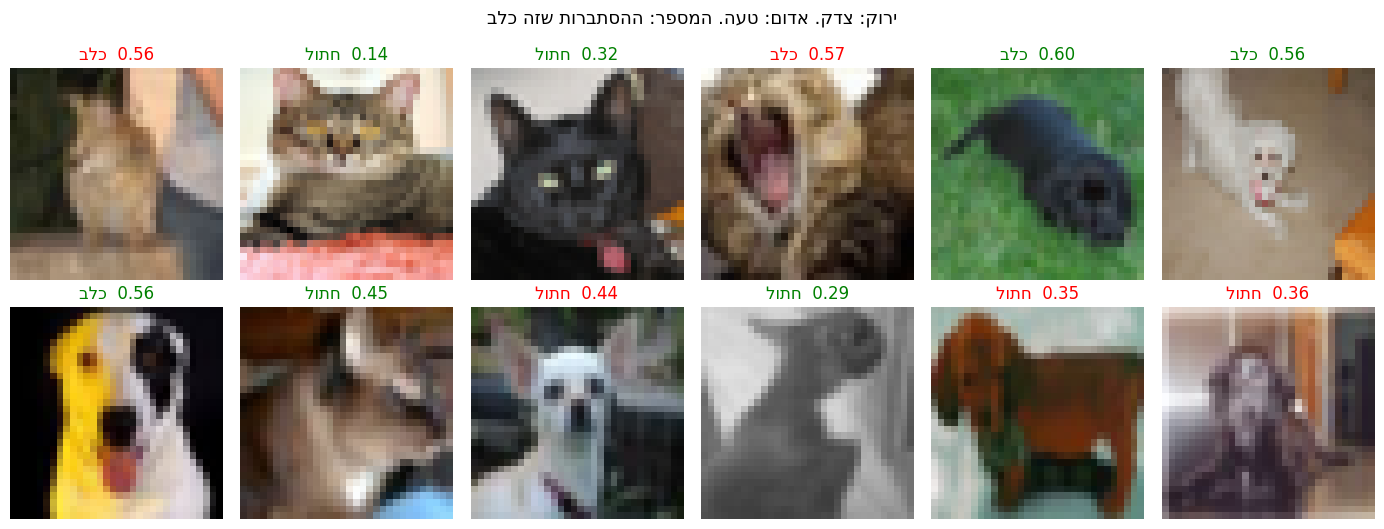

In [18]:
# כמה דוגמאות מסט המבחן, עם ההסתברות שהמודל נתן לכלב
probs = forward(w, b, X_test)
show = np.random.choice(len(X_test), 12, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(14, 5.5))
for ax, i in zip(axes.flat, show):
    ax.imshow(X_test_img[i]); ax.axis('off')
    guess = 'כלב' if probs[i] > 0.5 else 'חתול'
    correct = (probs[i] > 0.5) == (y_test[i] == 1)
    ax.set_title(heb(guess) + f'  {probs[i]:.2f}', color='green' if correct else 'red', fontsize=12)
plt.suptitle(heb('ירוק: צדק. אדום: טעה. המספר: ההסתברות שזה כלב'), fontsize=13)
plt.tight_layout(); plt.show()

<div dir=rtl style="text-align: right">

### מה הנוירון למד?

ל-$\mathbf{w}$ יש בדיוק 3072 רכיבים, אחד לכל פיקסל וערוץ צבע, אז אפשר לסדר אותו בחזרה כתמונה. מה שנקבל הוא ה"תבנית" שהנוירון משווה אליה: פיקסלים עם משקל חיובי מצביעים לטובת כלב, פיקסלים עם משקל שלילי לטובת חתול. (מכיוון שאימנו על פיצ'רים מתוקננים, נחלק ב-$\sigma_j$ כדי לחזור לסקאלת הפיקסלים.)

אל תצפו לראות כלב. התבנית רועשת, ורק במרכז התמונה יש מבנה שמזכיר משהו. זה בדיוק מה שתבנית לינארית אחת מסוגלת ללמוד מפיקסלים גולמיים, ולא יותר.

</div>

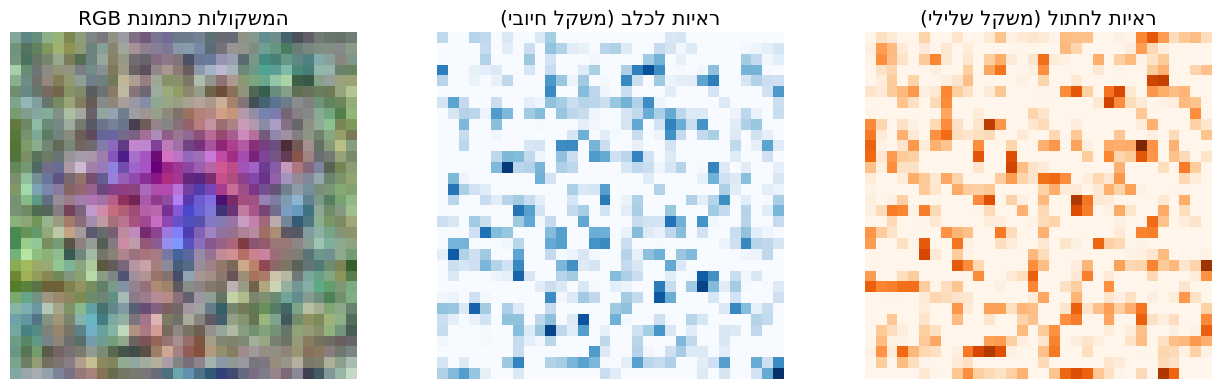

In [19]:
template = (w / sigma).reshape(32, 32, 3)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
img = (template - template.min()) / (template.max() - template.min())
axes[0].imshow(img); axes[0].set_title(heb('המשקולות כתמונת RGB'))
evidence = template.sum(axis=2)
lim = np.abs(evidence).max()
axes[1].imshow(np.maximum(evidence, 0), cmap='Blues', vmin=0, vmax=lim); axes[1].set_title(heb('ראיות לכלב (משקל חיובי)'))
axes[2].imshow(np.maximum(-evidence, 0), cmap='Oranges', vmin=0, vmax=lim); axes[2].set_title(heb('ראיות לחתול (משקל שלילי)'))
for ax in axes:
    ax.axis('off')
plt.tight_layout(); plt.show()

<div dir=rtl style="text-align: right">

## 9. סיכום

**מה בנינו:** מסווג חתול/כלב שלם, מהורדת הנתונים ועד מדידה על סט המבחן, ב-NumPy בלבד. הוא מגיע לדיוק של כ-61%. זה הרבה יותר מניחוש, והרבה פחות ממה שאפשר. הסיבה ברורה: מודל **לינארי** על פיקסלים גולמיים משווה כל תמונה לתבנית אחת קבועה, ואילו חתולים וכלבים מופיעים בכל גודל, זווית, צבע ורקע. השיעורים הבאים בקורס עוסקים בדיוק בזה: שכבות חבויות ואי-לינאריות (שכבה חבויה אחת כבר מעלה את הדיוק על אותם נתונים לכ-65%), חילוץ פיצ'רים, ורשתות קונבולוציה (שעוברות 85% על הזוג הזה).

**מה למדנו על הגרדיאנט:**

- ההגדרה של הנגזרת נותנת אלגוריתם ישיר: להזיז ולמדוד. ההפרש המרכזי מדויק בערך פי $1/\varepsilon$ מהקדמי, וקיים $\varepsilon$ אופטימלי (בסביבות $10^{-5}$) בגלל שגיאות העיגול.
- כלל השרשרת נותן נוסחה סגורה. עבור סיגמואיד ואנטרופיה צולבת היא יפה במיוחד: $\nabla_{\mathbf{w}} J = \frac{1}{m} X^{\top}(\hat{\mathbf{y}} - \mathbf{y})$, כלומר סכום משוקלל של התמונות לפי השגיאה.
- שתי הדרכים מסכימות עד לספרה העשירית. הסימבולית זולה פי אלפים, וזה מה שהופך אימון של מודלים גדולים לאפשרי. הנומרית נשארת ככלי הבדיקה של הסימבולית.

**מה למדנו על SGD:** גרדיאנט על מיני-אצווה אקראית הוא אומדן רועש אבל לא מוטה של הגרדיאנט המלא, וזול פי $N/m$. הרעש נראה בבירור בעקומת ההפסד לפי צעד, ונעלם כשמסתכלים לפי אפוק.

### תרגילים

1. **הפרש קדמי.** כתבו `numeric_gradient_forward` שמשתמשת ב-$\frac{J(\theta+\varepsilon e_j) - J(\theta)}{\varepsilon}$, וחזרו על ניסוי ה-$\varepsilon$ של סעיף 7.2. איפה המינימום עכשיו, וכמה הוא גרוע יותר?
2. **רגולריזציה.** הוסיפו ל-$J$ את האיבר $\frac{\lambda}{2}\|\mathbf{w}\|^2$. גזרו את הגרדיאנט החדש, ממשו, ואמתו נומרית. האם התאמת-היתר קטנה?
3. **גודל האצווה.** אמנו עם $m = 1$, $m = 16$ ו-$m = 512$ באותו מספר אפוקים. השוו את הרעש בעקומת ההפסד, את הזמן, ואת הדיוק הסופי.
4. **הפסד ריבועי.** החליפו את האנטרופיה הצולבת ב-$\ell = (\hat{y} - y)^2$. גזרו את $\frac{\partial \ell}{\partial z}$ (הפעם הסיגמואיד לא תצטמצם), ובדקו האם האימון מתכנס באותה מהירות.

</div>